# **Project Overview**

Imports

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import os
import time

Environment Setup & Reproducibility

In [4]:
'''
Sets the seed of the entire notebook so results are the same every time we run.
This's for reproducibility of results.
'''
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make cuDNN deterministic (slightly slower but fully reproducible)
torch.backends.cudnn.deterministic = True
# Disable auto-tuner (non-deterministic)
torch.backends.cudnn.benchmark = False

Golden Rule 1: Data Quality & Quantity

### **Dataset overview:**

**CIFAR-10:**
- 60,000 color images (32×32 pixels, 3 channels = RGB)
- 10 balanced classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Pre-labeled and curated → satisfies the **data quality** requirement out of the box
- 6,000 images per class → satisfies **balance** (no class imbalance problem)

>The dataset already exists in pytorch(built-in), so we will directly use it.

In [5]:
# create a
raw_transform = transforms.ToTensor()

# load dataset and convert it into tensors to inspect it only for now
raw_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=raw_transform)
raw_test  = datasets.CIFAR10(root='./data', train=False, download=True, transform=raw_transform)

100%|██████████| 170M/170M [00:10<00:00, 15.8MB/s]


In [6]:
# saving all CIFAR-10 class names (10 categories) in a tuple for furtner inspection and visulaization
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck')

# print some info about the rreow data and train and test ratios as well
print('          CIFAR-10 DATASET OVERVIEW')
print('═' * 50)
print(f'  Training samples : {len(raw_train):,}')
print(f'  Test samples     : {len(raw_test):,}')
print(f'  Image shape      : {raw_train[0][0].shape}  (C x H x W)')
print(f'  Number of classes: {len(CLASSES)}')
print(f'  Classes          : {CLASSES}')

          CIFAR-10 DATASET OVERVIEW
══════════════════════════════════════════════════
  Training samples : 50,000
  Test samples     : 10,000
  Image shape      : torch.Size([3, 32, 32])  (C x H x W)
  Number of classes: 10
  Classes          : ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [7]:
# Count labels to verify the dataset is balanced (as this will affect why way we deal with the dataset later on when classifing)
# abd also to avoid any bais that may occure in the model
label_counts = Counter([label for _, label in raw_train])
print('\n📊 Samples per class (training):')

for i, cls in enumerate(CLASSES):
    bar = '█' * (label_counts[i] // 200)
    print(f'  {cls:<12} : {label_counts[i]:,}  {bar}')


📊 Samples per class (training):
  airplane     : 5,000  █████████████████████████
  automobile   : 5,000  █████████████████████████
  bird         : 5,000  █████████████████████████
  cat          : 5,000  █████████████████████████
  deer         : 5,000  █████████████████████████
  dog          : 5,000  █████████████████████████
  frog         : 5,000  █████████████████████████
  horse        : 5,000  █████████████████████████
  ship         : 5,000  █████████████████████████
  truck        : 5,000  █████████████████████████


> from the above we can clearly notice that all classes have equal number of samples
(**a balanced dataset**)

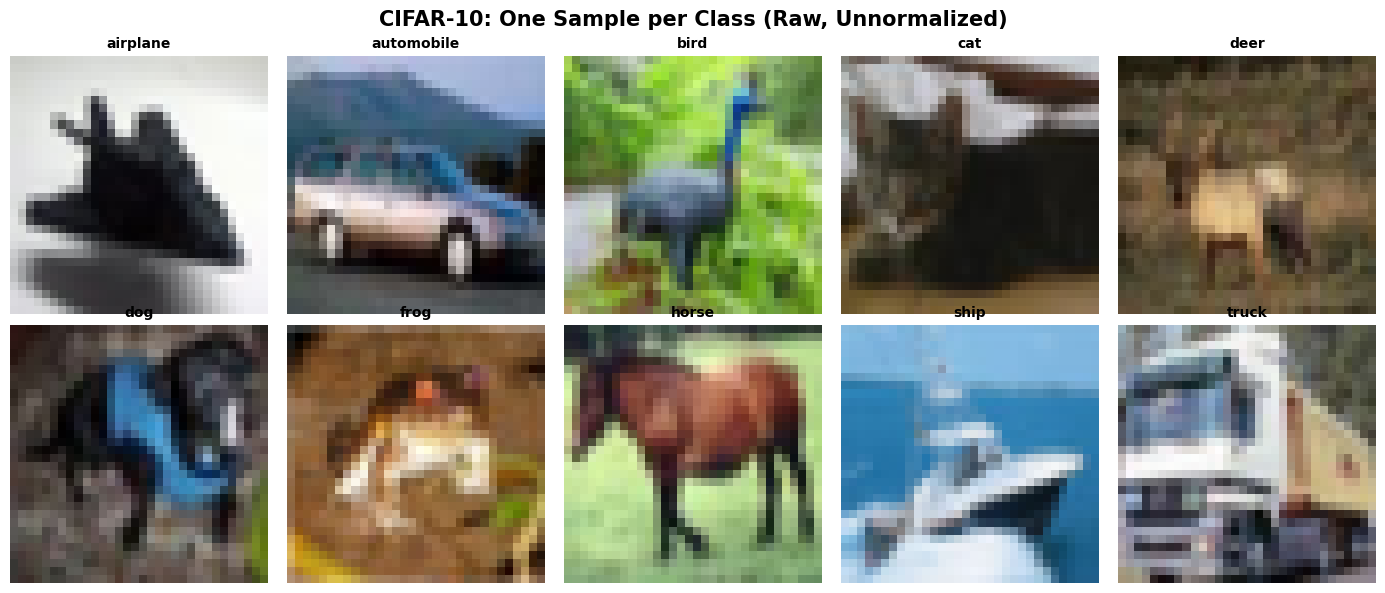

In [11]:
# visualize a row sample image of each class with displaying their labels
# this step in important to see n=and have an idea about the dataset and their current quality
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAR-10: One Sample per Class (Raw, Unnormalized)',
             fontsize=15, fontweight='bold')

# Find one example of each class
shown = {i: False for i in range(10)}
for img, label in raw_train:
    if not shown[label]:
        ax = axes[label // 5][label % 5]
        # Convert (C, H, W) → (H, W, C) for matplotlib
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(CLASSES[label], fontsize=10, fontweight='bold')
        ax.axis('off')
        shown[label] = True
    if all(shown.values()):
        break

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# **Golden Rule 3: Split Your Data**

> **"Always divide your dataset into training, validation, and test sets to detect overfitting."**

**Three-way split strategy:**
| Split | Size | Purpose |
|-------|------|------|
| Training | 45,000 (90%) | for model to train on |
| Validation | 5,000 (10%) | for hyperparameters tuning and to detect overfitting |
| Test | 10,000 (fixed) | Final unbiased evaluation (loaded from pytorch datasets) |

⚠️ **Key rule:** Never use test data during training or hyperparameter tuning! To avoid any data leakage that may occure

In [12]:
# We must compute mean/std ONLY on the training set (not val/test)
# to prevent data leakage.

# Stack all training images into one tensor (shape: N, C, H, W)
all_train_data = torch.stack([img for img, _ in raw_train])  # (50000, 3, 32, 32)

# Compute per-channel mean and std across all pixels and images
# Reshape to (N*H*W, C) then compute stats per channel
train_mean = all_train_data.mean(dim=[0, 2, 3])  # mean per channel
train_std  = all_train_data.std(dim=[0, 2, 3])   # std per channel

print('Training Set Normalization Statistics:')
print(f'   Mean (R, G, B): ({train_mean[0]:.4f}, {train_mean[1]:.4f}, {train_mean[2]:.4f})')
print(f'   Std  (R, G, B): ({train_std[0]:.4f},  {train_std[1]:.4f},  {train_std[2]:.4f})')
print()
print('These values will be used in the Normalize transform.')
print('Applying same stats to val/test (no data leakage — stats from train only)')

Training Set Normalization Statistics:
   Mean (R, G, B): (0.4914, 0.4822, 0.4465)
   Std  (R, G, B): (0.2470,  0.2435,  0.2616)

These values will be used in the Normalize transform.
Applying same stats to val/test (no data leakage — stats from train only)


# **Golden Rules 5 & 10: Normalize Data + Data Augmentation**

### Golden Rule 5: Normalize
> Normalization shifts input values to have **zero mean and unit variance**, which:
> - Prevents exploding/vanishing gradients  
> - Allows the optimizer to converge faster  
> - Makes all input channels equally scaled

### Golden Rule 10: Data Augmentation
> Artificially expand training data by applying **random transformations** that preserve the label:
> - `RandomHorizontalFlip` → a cat flipped horizontally is still a cat  
> - `RandomCrop` → teaches position invariance  
> - `ColorJitter` → teaches color/lighting invariance  

⚠️ **Augmentation is applied ONLY to training data — never to validation or test!**

In [13]:
# the calcualted statistica of the data from the previous step
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# TRAINING transform: Augmentation + Normalization
# Each epoch, different random crops/flips are applied → more diverse training
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),        # Pad 4px then random crop back to 32
    transforms.RandomHorizontalFlip(p=0.5),      # 50% chance of horizontal flip
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,            # Vary brightness & contrast ±20%
        saturation=0.2, hue=0.1),                # Vary saturation/hue slightly
    transforms.ToTensor(),                       # PIL Image → FloatTensor [0,1]
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)  # Normalize to ~N(0,1)
])

# VALIDATION & TEST transform: Normalize ONLY (to avoid data leakeage which results in having a biased model)
# We want a stable, unmodified evaluation signal.
eval_transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

print('✅ Transforms defined:')
print('   train_transform → RandomCrop + HorizontalFlip + ColorJitter + Normalize')
print('   eval_transform  → ToTensor + Normalize (NO augmentation)')

✅ Transforms defined:
   train_transform → RandomCrop + HorizontalFlip + ColorJitter + Normalize
   eval_transform  → ToTensor + Normalize (NO augmentation)


In [14]:
# spliting the data into proper sets

# Load full training set WITH training transforms defined above (normalization + augmentation)
full_train_dataset = datasets.CIFAR10(root='./data', train=True,
                                       download=False, transform=train_transform)

# Load full training set WITHOUT transforms (for validation split)
# We'll apply eval_transform to the validation portion separately
full_eval_dataset  = datasets.CIFAR10(root='./data', train=True,
                                       download=False, transform=eval_transform)

# Split indices: 45,000 train / 5,000 validation
# Use generator with fixed seed for reproducibility
generator = torch.Generator().manual_seed(SEED)
train_size = 45_000
val_size   =  5_000

train_indices, val_indices = random_split(range(len(full_train_dataset)),[train_size, val_size],generator=generator)

# Create Subset datasets with correct transforms
from torch.utils.data import Subset
train_dataset = Subset(full_train_dataset, train_indices.indices)
val_dataset   = Subset(full_eval_dataset,  val_indices.indices)

# Test dataset always uses eval_transform
test_dataset = datasets.CIFAR10(root='./data', train=False,download=False, transform=eval_transform)

print('✅ Dataset splits created:')
print(f'   Training   : {len(train_dataset):,} samples  (augmented)')
print(f'   Validation : {len(val_dataset):,} samples  (clean)')
print(f'   Test       : {len(test_dataset):,} samples  (clean, touch at end only!)')

✅ Dataset splits created:
   Training   : 45,000 samples  (augmented)
   Validation : 5,000 samples  (clean)
   Test       : 10,000 samples  (clean, touch at end only!)


# **Golden Rule 8: Shuffle Data + Create DataLoaders**

> **"Shuffle the training set so the network does not learn the order of examples."**

**Why shuffling matters:**
- Without shuffling, the model sees classes in the same order every epoch  
- This creates **systematic bias** — the optimizer's gradients become correlated  
- Shuffling ensures each mini-batch is a **random mix of all classes**

In [15]:
BATCH_SIZE  = 128    # Mini-batch size: powers of 2 work best for GPU efficiency
NUM_WORKERS = 2      # Parallel data loading threads (use 4+ on powerful machines)

# shuffle=True  → data order randomized every epoch (Golden Rule 8)
# pin_memory    → lock CPU memory pages → faster GPU transfer
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=True,drop_last=True)

# shuffle=False → deterministic evaluation every epoch
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False, num_workers=NUM_WORKERS,pin_memory=True)
test_loader = DataLoader( test_dataset, batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)

print('✅ DataLoaders created:')
print(f'   Batch size        : {BATCH_SIZE}')
print(f'   Training batches  : {len(train_loader)}')
print(f'   Validation batches: {len(val_loader)}')
print(f'   Test batches      : {len(test_loader)}')

# Verify a single batch shape
sample_batch, sample_labels = next(iter(train_loader))
print(f'\n   Sample batch shape : {sample_batch.shape}  (N, C, H, W)')
print(f'   Sample labels shape: {sample_labels.shape}')
print(f'   Pixel value range  : [{sample_batch.min():.3f}, {sample_batch.max():.3f}]  (normalized)')

✅ DataLoaders created:
   Batch size        : 128
   Training batches  : 351
   Validation batches: 40
   Test batches      : 79


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



   Sample batch shape : torch.Size([128, 3, 32, 32])  (N, C, H, W)
   Sample labels shape: torch.Size([128])
   Pixel value range  : [-1.989, 2.126]  (normalized)


# **Golden Rule 2: Start Simple (Baseline Model)**

In [19]:
# Define device before model instantiation
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

class BaselineCNN(nn.Module):
    """
    Minimal CNN baseline — 2 conv layers + 2 FC layers.
    Used to:
      1) Verify the training pipeline works end-to-end
      2) Establish a performance floor to beat with the full model
    Architecture: Conv→ReLU→Pool → Conv→ReLU→Pool → FC→ReLU → FC (output)
    """

    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        # Convolutional Feature Extractor (at the first beginning layers)
        self.features = nn.Sequential(
            # Block 1: 3 input channels (RGB) → 32 feature maps
            nn.Conv2d(in_channels=3, out_channels=32,
                      kernel_size=3, padding=1),  # (3,32,32) → (32,32,32)
            nn.ReLU(inplace=True),                # Golden Rule 6: ReLU for hidden layers
            nn.MaxPool2d(kernel_size=2, stride=2),# (32,32,32) → (32,16,16)

            # Block 2: 32 → 64 feature maps
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (32,16,16) → (64,16,16)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # (64,16,16) → (64,8,8)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                    # (64,8,8) → (64*8*8) = 4096
            nn.Linear(64 * 8 * 8, 256),     # Fully connected layer
            nn.ReLU(inplace=True),           # ReLU activation
            nn.Linear(256, num_classes),     # Output: 10 logits (one per class)
            # No softmax here — CrossEntropyLoss includes it internally
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x  # Raw logits


# Instantiate and inspect
baseline_model = BaselineCNN(num_classes=10).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)

print('Baseline CNN Architecture:')
print(baseline_model)
print(f'\n   Total parameters     : {total_params:,}')
print(f'   Trainable parameters : {trainable_params:,}')

# Quick forward pass sanity check
dummy = torch.randn(4, 3, 32, 32).to(DEVICE)
out   = baseline_model(dummy)
print(f'\n   Input shape  : {dummy.shape}')
print(f'   Output shape : {out.shape}  ← (batch_size, num_classes)')

Using device: cpu
Baseline CNN Architecture:
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

   Total parameters     : 1,070,794
   Trainable parameters : 1,070,794

   Input shape  : torch.Size([4, 3, 32, 32])
   Output shape : torch.Size([4, 10])  ← (batch_size, num_classes)


In [20]:
# Before training on full data, verify the model can really learn.
# you take 100 samples and try to get ~100% training accuracy.
#   --> If the model can't overfit 100 samples, something is wrong.

from torch.utils.data import TensorDataset

# Grab 100 samples from the training loader
tiny_imgs, tiny_labels = [], []
for imgs, labels in train_loader:
    tiny_imgs.append(imgs[:100])
    tiny_labels.append(labels[:100])
    break  # Only first batch

tiny_imgs   = tiny_imgs[0].to(DEVICE)
tiny_labels = tiny_labels[0].to(DEVICE)

# Overfit test: 300 gradient steps on just 100 samples
overfit_model = BaselineCNN(num_classes=10).to(DEVICE)
overfit_opt   = optim.Adam(overfit_model.parameters(), lr=1e-3)
criterion     = nn.CrossEntropyLoss()

print('Training on 100 samples for 300 steps...')
overfit_model.train()
for step in range(300):
    overfit_opt.zero_grad()
    logits = overfit_model(tiny_imgs)
    loss   = criterion(logits, tiny_labels)
    loss.backward()
    overfit_opt.step()

    if (step + 1) % 100 == 0:
        preds   = logits.argmax(dim=1)
        acc     = (preds == tiny_labels).float().mean().item()
        print(f'   Step {step+1:3d}/300 | Loss: {loss.item():.4f} | Acc: {acc*100:.1f}%')

print('\n Overfit test complete!')
print('   If final accuracy ≥ 95%, the model and pipeline are working correctly.')
del overfit_model  # a cleaning step (best practice)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🔬 Overfit Test: Training on 100 samples for 300 steps...
   Step 100/300 | Loss: 0.0001 | Acc: 100.0%
   Step 200/300 | Loss: 0.0001 | Acc: 100.0%
   Step 300/300 | Loss: 0.0001 | Acc: 100.0%

 Overfit test complete!
   If final accuracy ≥ 95%, the model and pipeline are working correctly.


# **Full Model: Golden Rules 6, 7, 9 Combined**

ow we build the **full improved model** applying:

| Golden Rule | Technique | Where Applied |
|---|---|---|
| Rule 6 | ReLU activation (hidden), Softmax (output via CrossEntropy) | After every Conv/FC |
| Rule 7 | Dropout (p=0.5) + L2 weight decay | After FC layers, in optimizer |
| Rule 9 | Batch Normalization | After every Conv layer |

**Architecture:** 3-block VGG-style CNN with BatchNorm, Dropout, and skip-friendly depth.

In [22]:
class ImprovedCNN(nn.Module):
    """
    3-block CNN applying all Golden Rules:
      - Golden Rule 6: ReLU for all hidden layers
      - Golden Rule 9: BatchNorm after every Conv (before ReLU)
      - Golden Rule 7: Dropout(0.5) in FC layers to prevent overfitting
      - Output: raw logits (softmax is inside CrossEntropyLoss)

    Architecture:
      Block1: Conv(3→64)→BN→ReLU → Conv(64→64)→BN→ReLU → MaxPool
      Block2: Conv(64→128)→BN→ReLU → Conv(128→128)→BN→ReLU → MaxPool
      Block3: Conv(128→256)→BN→ReLU → Conv(256→256)→BN→ReLU → AdaptiveAvgPool
      Head:   FC(256→512)→ReLU→Drop → FC(512→256)→ReLU→Drop → FC(256→10)
    """

    def __init__(self, num_classes=10, dropout_p=0.5):
        super(ImprovedCNN, self).__init__()

        # ── BLOCK 1: Low-level edge & color detection ─────────
        # Input: (batch, 3, 32, 32) → Output: (batch, 64, 16, 16)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # ── BLOCK 2: Mid-level pattern detection ──────────────
        # Input: (batch, 64, 16, 16) → Output: (batch, 128, 8, 8)
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),       # 16×16 → 8×8
        )

        # ── BLOCK 3: High-level semantic features ─────────────
        # Input: (batch, 128, 8, 8) → Output: (batch, 256, 4, 4)
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        # ── CLASSIFIER HEAD ────────────────────────────────────
        # Input: 256 * 4 * 4 = 4096 → Output: 10 logits
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p / 2),
            nn.Linear(256, num_classes),
        )

        # ── WEIGHT INITIALIZATION ──────────────────────────────
        # He (Kaiming) initialization works best with ReLU activations
        self._initialize_weights()

    def _initialize_weights(self):
        """Kaiming He initialization for Conv layers, Xavier for Linear."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)  # Scale = 1
                nn.init.constant_(m.bias, 0)    # Shift = 0
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ─── Instantiate full model ───────────────────────────────────
model = ImprovedCNN(num_classes=10, dropout_p=0.5).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('ImprovedCNN Architecture:')
print(model)
print(f'\n   Total parameters     : {total_params:,}')
print(f'   Trainable parameters : {trainable_params:,}')

ImprovedCNN Architecture:
ImprovedCNN(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0

# **Golden Rule 10: Learning Rate Selection**

*The strategy:**
1. Use **Adam optimizer** (adaptive learning rate per parameter)
2. Start with `lr = 1e-3` (well-established default for Adam)
3. Apply **ReduceLROnPlateau** scheduler — halves LR when val loss stops improving
4. Use **L2 weight decay** (`weight_decay=1e-4`) in the optimizer → implements L2 regularization (Golden Rule 7)

This combination is the industry-standard starting point for image classification.

In [24]:
# ─── Loss Function ───────────────────────────────────────────
# CrossEntropyLoss = LogSoftmax + NLLLoss
# Automatically handles the softmax → satisfies Golden Rule 6 for output layer
criterion = nn.CrossEntropyLoss()

# ─── Optimizer ───────────────────────────────────────────────
# Adam: adaptive learning rates per parameter, momentum built-in
# weight_decay=1e-4 → L2 regularization (penalizes large weights)

LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ─── Learning Rate Scheduler ─────────────────────────────────
# ReduceLROnPlateau: reduce LR when validation loss stops improving
# patience=5: wait 5 epochs with no improvement before reducing
# factor=0.5: multiply LR by 0.5 (halve it)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print('✅ Optimizer: Adam')
print(f'   Initial LR     : {LEARNING_RATE}')
print(f'   Weight decay   : {WEIGHT_DECAY}  (L2 regularization)')
print(f'\n✅ Scheduler: ReduceLROnPlateau')
print(f'   Monitors       : validation loss')
print(f'   Patience       : 5 epochs')
print(f'   Factor         : 0.5 (halves LR on plateau)')
print(f'\n✅ Loss: CrossEntropyLoss (includes softmax internally)')

✅ Optimizer: Adam
   Initial LR     : 0.001
   Weight decay   : 0.0001  (L2 regularization)

✅ Scheduler: ReduceLROnPlateau
   Monitors       : validation loss
   Patience       : 5 epochs
   Factor         : 0.5 (halves LR on plateau)

✅ Loss: CrossEntropyLoss (includes softmax internally)


# **Golden Rule 4: Monitor Loss & Metrics + Full Training Loop**

### **we track per epoch:**
- Training loss & accuracy
- Validation loss & accuracy
- Learning rate (to observe scheduler behavior)

In [25]:
# train_acc >> val_acc → overfitting (increase regularization)
# Both accuracies low → underfitting (increase model capacity or train longer)
# Both improving together → healthy training

# ============================================================
# CELL 12: Training Helper Functions
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Run one full epoch of training.
    Returns: (average_loss, accuracy)
    """
    model.train()  # Enable dropout + batch norm in training mode
    running_loss = 0.0
    correct = 0
    total   = 0

    for batch_imgs, batch_labels in loader:
        # Move data to device (GPU if available)
        batch_imgs   = batch_imgs.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        # ── Forward pass ──────────────────────────────────────
        optimizer.zero_grad()
        logits = model(batch_imgs)
        loss   = criterion(logits, batch_labels)

        # ── Backward pass ─────────────────────────────────────
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # ── Accumulate metrics ────────────────────────────────
        running_loss += loss.item() * batch_imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == batch_labels).sum().item()
        total   += batch_labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()  # Disable gradient computation for evaluation (faster + saves memory)
def evaluate(model, loader, criterion, device):
    """
    Evaluate model on a given DataLoader (validation or test).
    Returns: (average_loss, accuracy)
    """
    model.eval()  # Disable dropout, use running stats for BatchNorm
    running_loss = 0.0
    correct = 0
    total   = 0

    for batch_imgs, batch_labels in loader:
        batch_imgs   = batch_imgs.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        logits = model(batch_imgs)
        loss   = criterion(logits, batch_labels)

        running_loss += loss.item() * batch_imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == batch_labels).sum().item()
        total   += batch_labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


print('✅ Training and evaluation functions defined.')

✅ Training and evaluation functions defined.


In [ ]:
NUM_EPOCHS = 30         # Train for 30 epochs
CHECKPOINT_PATH = 'best_model.pth'  # Save best model weights

# ─── History storage ─────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'lr':         []
}

best_val_loss = float('inf')   # Track best validation loss for checkpointing
best_val_acc  = 0.0

print('🚀 Starting Training...')
print(f'   Epochs: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Device: {DEVICE}')
print('═' * 80)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8} | {"LR":>8}')
print('─' * 80)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # ── Validate ──────────────────────────────────────────────
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    # ── Step LR scheduler based on validation loss ────────────
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)

    # ── Log history ───────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # ── Save best model checkpoint ────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc  = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, CHECKPOINT_PATH)
        best_marker = ' ← BEST'
    else:
        best_marker = ''

    # ── Print progress ────────────────────────────────────────
    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc*100:>8.2f}% | '
          f'{val_loss:>8.4f} | {val_acc*100:>8.2f}%{best_marker} | {current_lr:.2e}')

elapsed = time.time() - start_time
print('═' * 80)
print(f'\nTraining complete in {elapsed/60:.1f} minutes')
print(f'   Best validation loss : {best_val_loss:.4f}')
print(f'   Best validation acc  : {best_val_acc*100:.2f}%')
print(f'   Checkpoint saved to  : {CHECKPOINT_PATH}')

🚀 Starting Training...
   Epochs: 30 | Batch size: 128 | Device: cpu
════════════════════════════════════════════════════════════════════════════════
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR
────────────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# Visualizing train vs. val curves is the primary tool for
# diagnosing overfitting, underfitting, and learning rate issues.

epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — Golden Rule 4: Monitor Loss & Metrics',
             fontsize=14, fontweight='bold')

# ── Plot 1: Loss curves ───────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=3, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'r-o', markersize=3, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Annotate: large gap = overfitting
ax1.annotate('Gap = overfitting signal', xy=(NUM_EPOCHS*0.6, 0.6), fontsize=9, color='gray')

# ── Plot 2: Accuracy curves ───────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, [a*100 for a in history['train_acc']],
         'b-o', markersize=3, label='Train Accuracy')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],
         'r-o', markersize=3, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Plot 3: Learning rate schedule ───────────────────────────
ax3 = axes[2]
ax3.semilogy(epochs_range, history['lr'], 'g-o', markersize=3)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate (log scale)')
ax3.set_title('Learning Rate Schedule')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved as training_curves.png')